In [8]:
# Load Data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("clean_players.csv")

In [9]:
# Aggregation
team_df = df.groupby('club_name').agg({
    'overall': 'mean',
    'pace': 'mean',
    'shooting': 'mean',
    'passing': 'mean',
    'dribbling': 'mean',
    'defending': 'mean',
    'physical': 'mean'
}).reset_index()
team_df.rename(columns={'overall': 'team_rating'}, inplace=True)

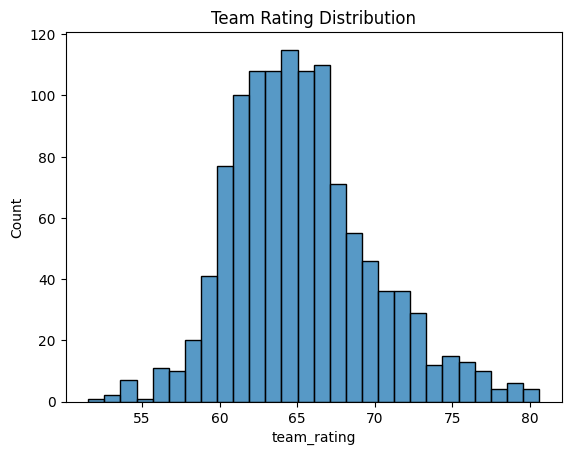

In [10]:
# EDA
plt.figure()
sns.histplot(team_df['team_rating'])
plt.title("Team Rating Distribution")
plt.show()

In [11]:
# Model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
X = team_df[['pace','shooting','passing','dribbling','defending','physical']]
y = team_df['team_rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [12]:
# Evaluation
pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("Team RMSE:", rmse)

Team RMSE: 0.8531657392243676


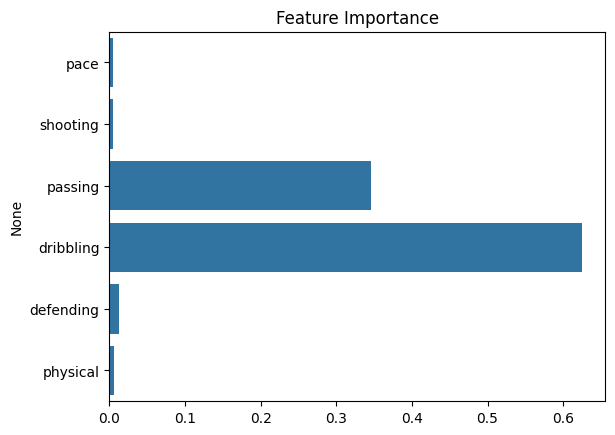

In [13]:
# Feature Importance
importances = model.feature_importances_
plt.figure()
sns.barplot(x=importances, y=X.columns)
plt.title("Feature Importance")
plt.show()

In [14]:
# Save Models
import joblib
joblib.dump(model, "team_model.pkl")
team_df.to_csv("team_data.csv", index=False)